In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

I0000 00:00:1779372749.181282   39714 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779372749.543111   39714 pjrt_api.cc:95] PJRT_Api is set for device type gpu
I0000 00:00:1779372749.624232   39714 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779372751.735513   39714 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
DATASET_DIR = Path("../urban_sound_dataset_split")
METADATA_PATH = DATASET_DIR / "clips_metadata_with_splits.csv"

df = pd.read_csv(METADATA_PATH)

print(df.head())
print("Total clips:", len(df))
print(df["split"].value_counts())
print(df["label"].value_counts())

              clip_filename                            relative_path  \
0  bs_ozyegin16_clip025.wav     bird_sounds\bs_ozyegin16_clip025.wav   
1    pt_plane01_clip007.wav  public_transport\pt_plane01_clip007.wav   
2    pt_plane02_clip005.wav  public_transport\pt_plane02_clip005.wav   
3     ft_koru09_clip003.wav          footsteps\ft_koru09_clip003.wav   
4      pt_bus01_clip034.WAV    public_transport\pt_bus01_clip034.WAV   

              label  duration_sec            device  split  
0       bird_sounds           NaN  Zoom H4essential  train  
1  public_transport           2.0  Zoom H4essential  train  
2  public_transport           2.0  Zoom H4essential  train  
3         footsteps           NaN  Zoom H4essential  train  
4  public_transport           NaN  Zoom H4essential  train  
Total clips: 1219
split
train    853
val      183
test     183
Name: count, dtype: int64
label
bird_sounds         175
public_transport    150
footsteps           150
traffic             150
siren     

In [3]:
TARGET_SR = 16000
TARGET_DURATION = 2.0
TARGET_LENGTH = int(TARGET_SR * TARGET_DURATION)

def load_audio_fixed(path, target_sr=TARGET_SR, target_length=TARGET_LENGTH):
    y, sr = librosa.load(path, sr=target_sr, mono=True)

    if len(y) < target_length:
        y = np.pad(y, (0, target_length - len(y)), mode="constant")
    else:
        y = y[:target_length]

    return y, target_sr

In [4]:
N_MELS = 64
N_FFT = 1024
HOP_LENGTH = 256

def extract_logmel(path):
    y, sr = load_audio_fixed(path)

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_fft=N_FFT,
        hop_length=HOP_LENGTH,
        n_mels=N_MELS
    )

    log_mel = librosa.power_to_db(mel, ref=np.max)

    # Normalize per sample
    log_mel = (log_mel - log_mel.mean()) / (log_mel.std() + 1e-8)

    return log_mel

In [5]:
X = []
y = []
splits = []

for idx, row in df.iterrows():
    file_path = DATASET_DIR / row["split"] / row["label"] / row["clip_filename"]

    log_mel = extract_logmel(file_path)

    X.append(log_mel)
    y.append(row["label"])
    splits.append(row["split"])

    if (idx + 1) % 100 == 0:
        print(f"Processed {idx + 1}/{len(df)} clips")

X = np.array(X)
y = np.array(y)
splits = np.array(splits)

print("X shape before channel:", X.shape)

X = X[..., np.newaxis]

print("X shape after channel:", X.shape)

Processed 100/1219 clips
Processed 200/1219 clips
Processed 300/1219 clips
Processed 400/1219 clips
Processed 500/1219 clips
Processed 600/1219 clips
Processed 700/1219 clips
Processed 800/1219 clips
Processed 900/1219 clips
Processed 1000/1219 clips
Processed 1100/1219 clips
Processed 1200/1219 clips
X shape before channel: (1219, 64, 126)
X shape after channel: (1219, 64, 126, 1)


In [6]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

num_classes = len(label_encoder.classes_)

print("Classes:")
for i, cls in enumerate(label_encoder.classes_):
    print(i, cls)

print("Number of classes:", num_classes)

train_mask = splits == "train"
val_mask = splits == "val"
test_mask = splits == "test"

X_train = X[train_mask]
X_val = X[val_mask]
X_test = X[test_mask]

y_train = y_encoded[train_mask]
y_val = y_encoded[val_mask]
y_test = y_encoded[test_mask]

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Classes:
0 bird_sounds
1 construction
2 crowd_chatter
3 footsteps
4 public_transport
5 siren
6 traffic
7 wind_trees
Number of classes: 8
Train: (853, 64, 126, 1) (853,)
Val: (183, 64, 126, 1) (183,)
Test: (183, 64, 126, 1) (183,)


In [7]:
input_shape = X_train.shape[1:]

def build_audio_cnn(input_shape, num_classes, dropout_dense=0.30):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.10),

        layers.Conv2D(64, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.15),

        layers.Conv2D(128, (3, 3), padding="same"),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.20),

        layers.GlobalAveragePooling2D(),

        layers.Dense(128, activation="relu"),
        layers.Dropout(dropout_dense),

        layers.Dense(num_classes, activation="softmax")
    ])

    return model

model = build_audio_cnn(input_shape, num_classes)
model.summary()

E0000 00:00:1779372934.774568   39714 cuda_executor.cc:1525] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
W0000 00:00:1779372935.065403   39714 gpu_device.cc:2364] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 126, 32)    │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 126, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 64, 126, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 63, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 63, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 63, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 31, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 31, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 16, 31, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 15, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 15, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │         1,032 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,112 (434.03 KB)

 Trainable params: 110,664 (432.28 KB)

 Non-trainable params: 448 (1.75 KB)

In [8]:
model = build_audio_cnn(input_shape, num_classes, dropout_dense=0.50)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [9]:
early_stop = callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=15,
    mode="max",
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Epoch 1/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 4s 103ms/step - accuracy: 0.1547 - loss: 2.3943 - val_accuracy: 0.1967 - val_loss: 2.0654 - learning_rate: 1.0000e-04
Epoch 2/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.2825 - loss: 1.9315 - val_accuracy: 0.1202 - val_loss: 2.0592 - learning_rate: 1.0000e-04
Epoch 3/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 94ms/step - accuracy: 0.3494 - loss: 1.7207 - val_accuracy: 0.1202 - val_loss: 2.0684 - learning_rate: 1.0000e-04
Epoch 4/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - accuracy: 0.4115 - loss: 1.5723 - val_accuracy: 0.1202 - val_loss: 2.0898 - learning_rate: 1.0000e-04
Epoch 5/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.4478 - loss: 1.5062 - val_accuracy: 0.1202 - val_loss: 2.1032 - learning_rate: 1.0000e-04
Epoch 6/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.5053 - loss: 1.4086 - val_accuracy: 0.2022 - val_loss: 2.1141 - learning_rate: 1.0000e-04
Epoch 7/100
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy:

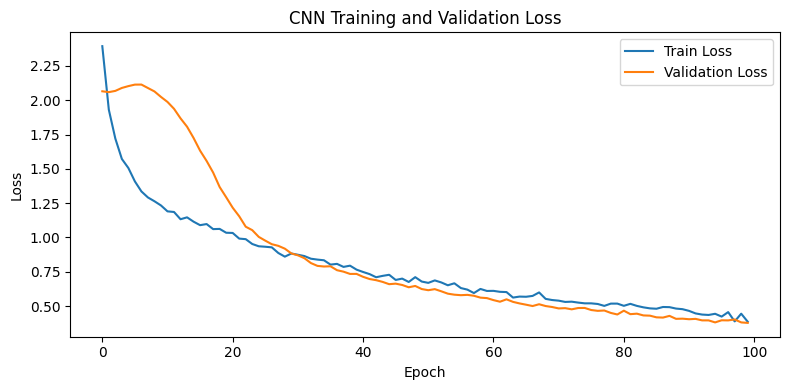

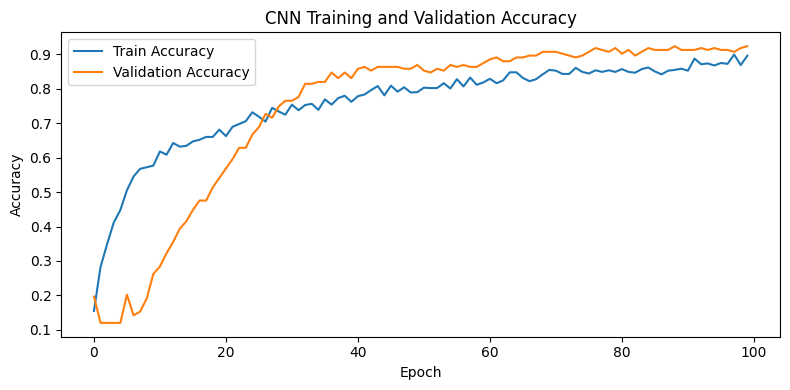

In [10]:
plt.figure(figsize=(8, 4))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("CNN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("CNN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()

In [11]:
val_probs = model.predict(X_val)
val_pred = np.argmax(val_probs, axis=1)

val_acc = accuracy_score(y_val, val_pred)
val_f1 = f1_score(y_val, val_pred, average="macro")

print("Validation Accuracy:", val_acc)
print("Validation Macro-F1:", val_f1)

print(classification_report(
    y_val,
    val_pred,
    target_names=label_encoder.classes_
))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Validation Accuracy: 0.9234972677595629
Validation Macro-F1: 0.9227109200657517
                  precision    recall  f1-score   support

     bird_sounds       0.96      0.96      0.96        27
    construction       0.85      0.96      0.90        23
   crowd_chatter       0.91      0.91      0.91        22
       footsteps       0.95      0.91      0.93        22
public_transport       0.88      0.95      0.91        22
           siren       1.00      0.91      0.95        23
         traffic       0.91      0.91      0.91        22
      wind_trees       0.95      0.86      0.90        22

        accuracy                           0.92       183
       macro avg       0.93      0.92      0.92       183
    weighted avg       0.93      0.92      0.92       183



In [12]:
test_probs = model.predict(X_test)
test_pred = np.argmax(test_probs, axis=1)

test_acc = accuracy_score(y_test, test_pred)
test_f1 = f1_score(y_test, test_pred, average="macro")

print("Test Accuracy:", test_acc)
print("Test Macro-F1:", test_f1)

print(classification_report(
    y_test,
    test_pred,
    target_names=label_encoder.classes_
))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Test Accuracy: 0.9289617486338798
Test Macro-F1: 0.9270943145117674
                  precision    recall  f1-score   support

     bird_sounds       0.96      1.00      0.98        26
    construction       0.91      0.95      0.93        22
   crowd_chatter       0.95      0.87      0.91        23
       footsteps       0.85      1.00      0.92        23
public_transport       0.84      0.91      0.88        23
           siren       1.00      1.00      1.00        22
         traffic       0.95      0.91      0.93        23
      wind_trees       1.00      0.76      0.86        21

        accuracy                           0.93       183
       macro avg       0.93      0.93      0.93       183
    weighted avg       0.93      0.93      0.93       183



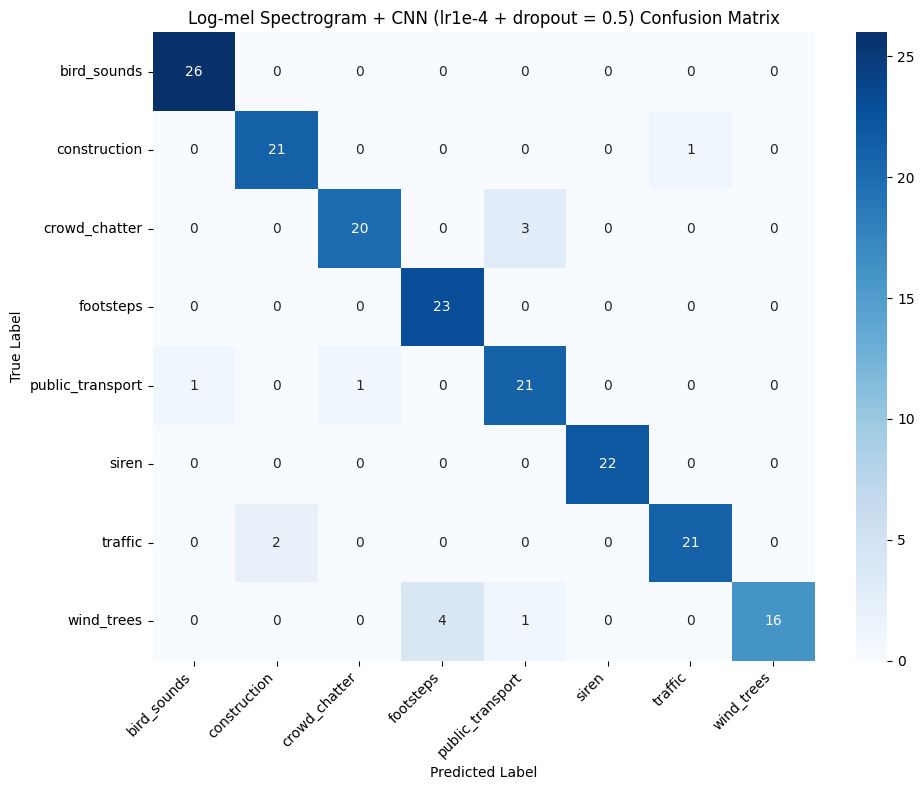

In [13]:
cm = confusion_matrix(y_test, test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Log-mel Spectrogram + CNN (lr1e-4 + dropout = 0.5) Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [14]:
RESULTS_DIR = Path("../results")
MODELS_DIR = Path("../models")

RESULTS_DIR.mkdir(exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

model.save(MODELS_DIR / "logmel_cnn_lr1e4_dropout50.keras")

cnn_results = {
    "model": "Log-mel CNN lr=1e-4 dropout=0.50",
    "experiment": "lr1e-4_dropout50",
    "features": "64-bin log-mel spectrogram",
    "validation_accuracy": val_acc,
    "validation_macro_f1": val_f1,
    "test_accuracy": test_acc,
    "test_macro_f1": test_f1,
    "architecture": "Conv32-Conv64-Conv128-GAP-Dense128",
    "learning_rate": 1e-4,
    "batch_size": 32,
    "dropout_dense": 0.50,
    "notes": "Lower learning rate and stronger dropout improved validation stability"
}

cnn_results_df = pd.DataFrame([cnn_results])
cnn_results_df.to_csv(
    RESULTS_DIR / "logmel_cnn_lr1e4_dropout50_results.csv",
    index=False
)

cnn_results_df

,model,experiment,features,validation_accuracy,validation_macro_f1,test_accuracy,test_macro_f1,architecture,learning_rate,batch_size,dropout_dense,notes
0,Log-mel CNN lr=1e-4 dropout=0.50,lr1e-4_dropout50,64-bin log-mel spectrogram,0.923497,0.922711,0.928962,0.927094,Conv32-Conv64-Conv128-GAP-Dense128,0.0001,32,0.5,Lower learning rate and stronger dropout impro...


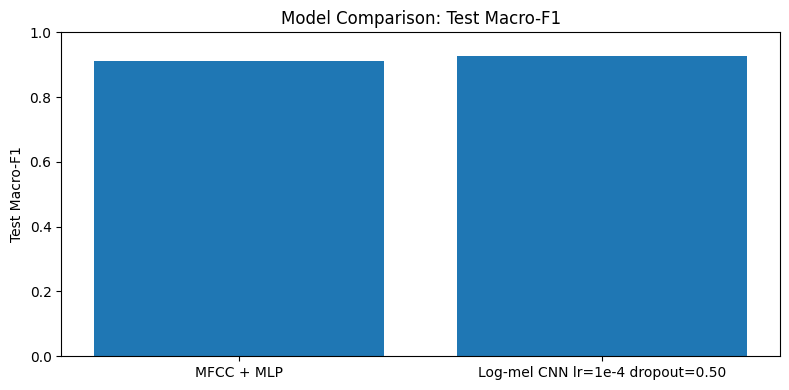

In [15]:
baseline_path = RESULTS_DIR / "mfcc_mlp_baseline_results.csv"
cnn_path = RESULTS_DIR / "logmel_cnn_lr1e4_dropout50_results.csv"

baseline_df = pd.read_csv(baseline_path)
cnn_df = pd.read_csv(cnn_path)

comparison_df = pd.concat([baseline_df, cnn_df], ignore_index=True)
comparison_df

plt.figure(figsize=(8, 4))
plt.bar(comparison_df["model"], comparison_df["test_macro_f1"])
plt.title("Model Comparison: Test Macro-F1")
plt.ylabel("Test Macro-F1")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()